In [21]:
# Loading the Libraries 
from prophet import Prophet
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Data Import and Cleaning

In [64]:
#Basic Data Cleaning Function
def load_cleaning (filepath):
    # Loading the data
    df = pd.read_excel(filepath,sheet_name="Estimates",header=[1],skiprows=0)
    #Keep only rows that are actual countries/regions(drop empty)
    df = df[pd.to_numeric(df['Year'], errors='coerce').notna()]
    df['Year'] = df['Year'].astype(int)
    # Filter Kenya + region + peers
    countries = ['KEN','UGA', 'TZA', 'ZAF', 'ETH']
    kenya_peers = df[df['Code'].isin(countries)].copy()
    kenya_peers['Country_Region'] = kenya_peers['Country_Region'].replace({'United Republic of Tanzania':'Tanzania'})
    return kenya_peers
    

In [65]:
# Loading and Cleaning data using the function.
kenya_peers = load_cleaning(r"D:\2026\Portfolio Data\HIV Estimates Data.xlsx")
kenya_peers.info()

<class 'pandas.DataFrame'>
Index: 175 entries, 1680 to 2134
Data columns (total 19 columns):
 #   Column                                                                                        Non-Null Count  Dtype 
---  ------                                                                                        --------------  ----- 
 0   Year                                                                                          175 non-null    int64 
 1   Code                                                                                          175 non-null    str   
 2   Country_Region                                                                                175 non-null    str   
 3   Adults (15-49) prevalence (%)-Estimate                                                        175 non-null    object
 4   Young women (15-24) prevalence (%)-Estimate                                                   175 non-null    object
 5   Young men (15-24) prevalence (%)- Estimate      

In [66]:
# A function to clean estimates recorded in millions to numbers e.g 1.1m to 1,100,000
def clean_estimate(x):
    x = str(x).lower().replace(',', '').strip()
    x = x.replace(' ', '')  # remove spaces
    
    if 'm' in x:
        return float(x.replace('m', '')) * 1_000_000
    else:
        return pd.to_numeric(x, errors='coerce')

#Apply it to multiple columns
cols = [
    'Adults and children newly infected with HIV- Estimate',
    'Adults (15+) newly infected with HIV- Estimate',
    'Estimated adults and children living with HIV- Estimate',
    'Estimated adults (15+) living with HIV- Estimate',
    'Estimated women (15+) living with HIV- Estimate',
    'Estimated children (0-14) living with HIV- Estimate',
    'AIDS-related deaths among adults and children- Estimate',
    'AIDS-related deaths among adults (15+)- Estimate'
]

kenya_peers[cols] = kenya_peers[cols].map(clean_estimate)

kenya_peers.info()

<class 'pandas.DataFrame'>
Index: 175 entries, 1680 to 2134
Data columns (total 19 columns):
 #   Column                                                                                        Non-Null Count  Dtype  
---  ------                                                                                        --------------  -----  
 0   Year                                                                                          175 non-null    int64  
 1   Code                                                                                          175 non-null    str    
 2   Country_Region                                                                                175 non-null    str    
 3   Adults (15-49) prevalence (%)-Estimate                                                        175 non-null    object 
 4   Young women (15-24) prevalence (%)-Estimate                                                   175 non-null    object 
 5   Young men (15-24) prevalence (%)- Estimat

In [67]:

#Cleaning numerical variables and converting them to the correct data type

float_cols =[
    'Adults (15-49) prevalence (%)-Estimate',
    'Young women (15-24) prevalence (%)-Estimate',
    'Young men (15-24) prevalence (%)- Estimate',
    'Adults (15-49) incidence (per 1000 uninfected population) - Estimate',
    'All ages incidence (per 1000 uninfected population)- Estimate'    
]
kenya_peers[float_cols] = kenya_peers[float_cols].replace('<0.1', 0.05)
kenya_peers[float_cols] = kenya_peers[float_cols].astype(float)


whole_numbers = ['AIDS-related deaths among adults and children- Estimate',
                'AIDS-related deaths among children (0-14)- Estimate',
                'AIDS-related deaths among adults (15+)- Estimate',
                'Estimated children (0-14) living with HIV- Estimate',
                'Estimated women (15+) living with HIV- Estimate',
                'Estimated adults (15+) living with HIV- Estimate',
                'Estimated adults and children living with HIV- Estimate',
                'Pregnant women needing antiretrovirals for preventing mother-to-child transmission -Estimate',
                'Children (0-14) newly infected with HIV- Estimate',
                'Adults (15+) newly infected with HIV- Estimate',
                'Adults and children newly infected with HIV- Estimate']
kenya_peers[whole_numbers] = (
    kenya_peers[whole_numbers]
    .replace(r'[\s\xa0]', '', regex=True)
    .apply(pd.to_numeric, errors='coerce')
    .round()
    .astype('Int64')
)


kenya_peers.info()

<class 'pandas.DataFrame'>
Index: 175 entries, 1680 to 2134
Data columns (total 19 columns):
 #   Column                                                                                        Non-Null Count  Dtype  
---  ------                                                                                        --------------  -----  
 0   Year                                                                                          175 non-null    int64  
 1   Code                                                                                          175 non-null    str    
 2   Country_Region                                                                                175 non-null    str    
 3   Adults (15-49) prevalence (%)-Estimate                                                        175 non-null    float64
 4   Young women (15-24) prevalence (%)-Estimate                                                   175 non-null    float64
 5   Young men (15-24) prevalence (%)- Estimat

In [68]:
# Renaming columns
kenya_peers.rename(columns={'Adults (15-49) prevalence (%)-Estimate':'adults_prev(%)',
                           'Young women (15-24) prevalence (%)-Estimate':'women_18_24_Prev(%)',
                           'Young men (15-24) prevalence (%)- Estimate':'men_18_24_prev(%)',
                           'AIDS-related deaths among adults and children- Estimate':'total_deaths',
                           'AIDS-related deaths among children (0-14)- Estimate':'total_children_deaths',
                           'AIDS-related deaths among adults (15+)- Estimate':'total_adults_deaths',
                           'Estimated children (0-14) living with HIV- Estimate':'children_with_hiv',
                           'Estimated women (15+) living with HIV- Estimate':'women_with_hiv',
                           'Estimated adults (15+) living with HIV- Estimate':'adults_with_hiv',
                           'Estimated adults and children living with HIV- Estimate':'total_hiv_pop',
                           'Adults (15-49) incidence (per 1000 uninfected population) - Estimate':'adults_incidence_1000_uninfectedpop',
                           'All ages incidence (per 1000 uninfected population)- Estimate':'total_incidence_1000_uninfectedpop', 
                           'Pregnant women needing antiretrovirals for preventing mother-to-child transmission -Estimate':'preg_women_antiretrovirals',
                           'Children (0-14) newly infected with HIV- Estimate':'newly_infected_children',
                           'Adults (15+) newly infected with HIV- Estimate':'newly_infected_adults',
                           'Adults and children newly infected with HIV- Estimate':'total_newly_infected',
                           'Country_Region':'country'},inplace=True)
kenya_peers.head()

,Year,Code,country,adults_prev(%),women_18_24_Prev(%),men_18_24_prev(%),total_deaths,total_children_deaths,total_adults_deaths,children_with_hiv,women_with_hiv,adults_with_hiv,total_hiv_pop,adults_incidence_1000_uninfectedpop,total_incidence_1000_uninfectedpop,preg_women_antiretrovirals,newly_infected_children,newly_infected_adults,total_newly_infected
1680,1990,ETH,Ethiopia,2.2,2.3,0.7,20000,8700,11000,40000,250000,430000,470000,6.3,3.4,29000,20000,120000,140000
1681,1991,ETH,Ethiopia,2.6,2.7,0.8,26000,11000,15000,52000,320000,540000,590000,6.5,3.6,37000,24000,130000,150000
1682,1992,ETH,Ethiopia,3.0,3.0,0.8,33000,13000,20000,64000,380000,630000,700000,6.0,3.4,44000,26000,120000,150000
1683,1993,ETH,Ethiopia,3.3,3.1,0.8,40000,14000,26000,76000,430000,710000,790000,5.3,3.1,50000,28000,110000,140000
1684,1994,ETH,Ethiopia,3.4,3.1,0.8,47000,15000,31000,88000,460000,760000,850000,4.3,2.7,55000,29000,91000,120000


In [69]:
#Exporting the cleaned data for storage.
kenya_peers.to_csv(r"D:\2026\Portfolio Data\cleaned_hiv_data.csv",index=False)

# Descrptive and Exploratory Analysis

In [70]:
kenya_peers.shape

(175, 19)

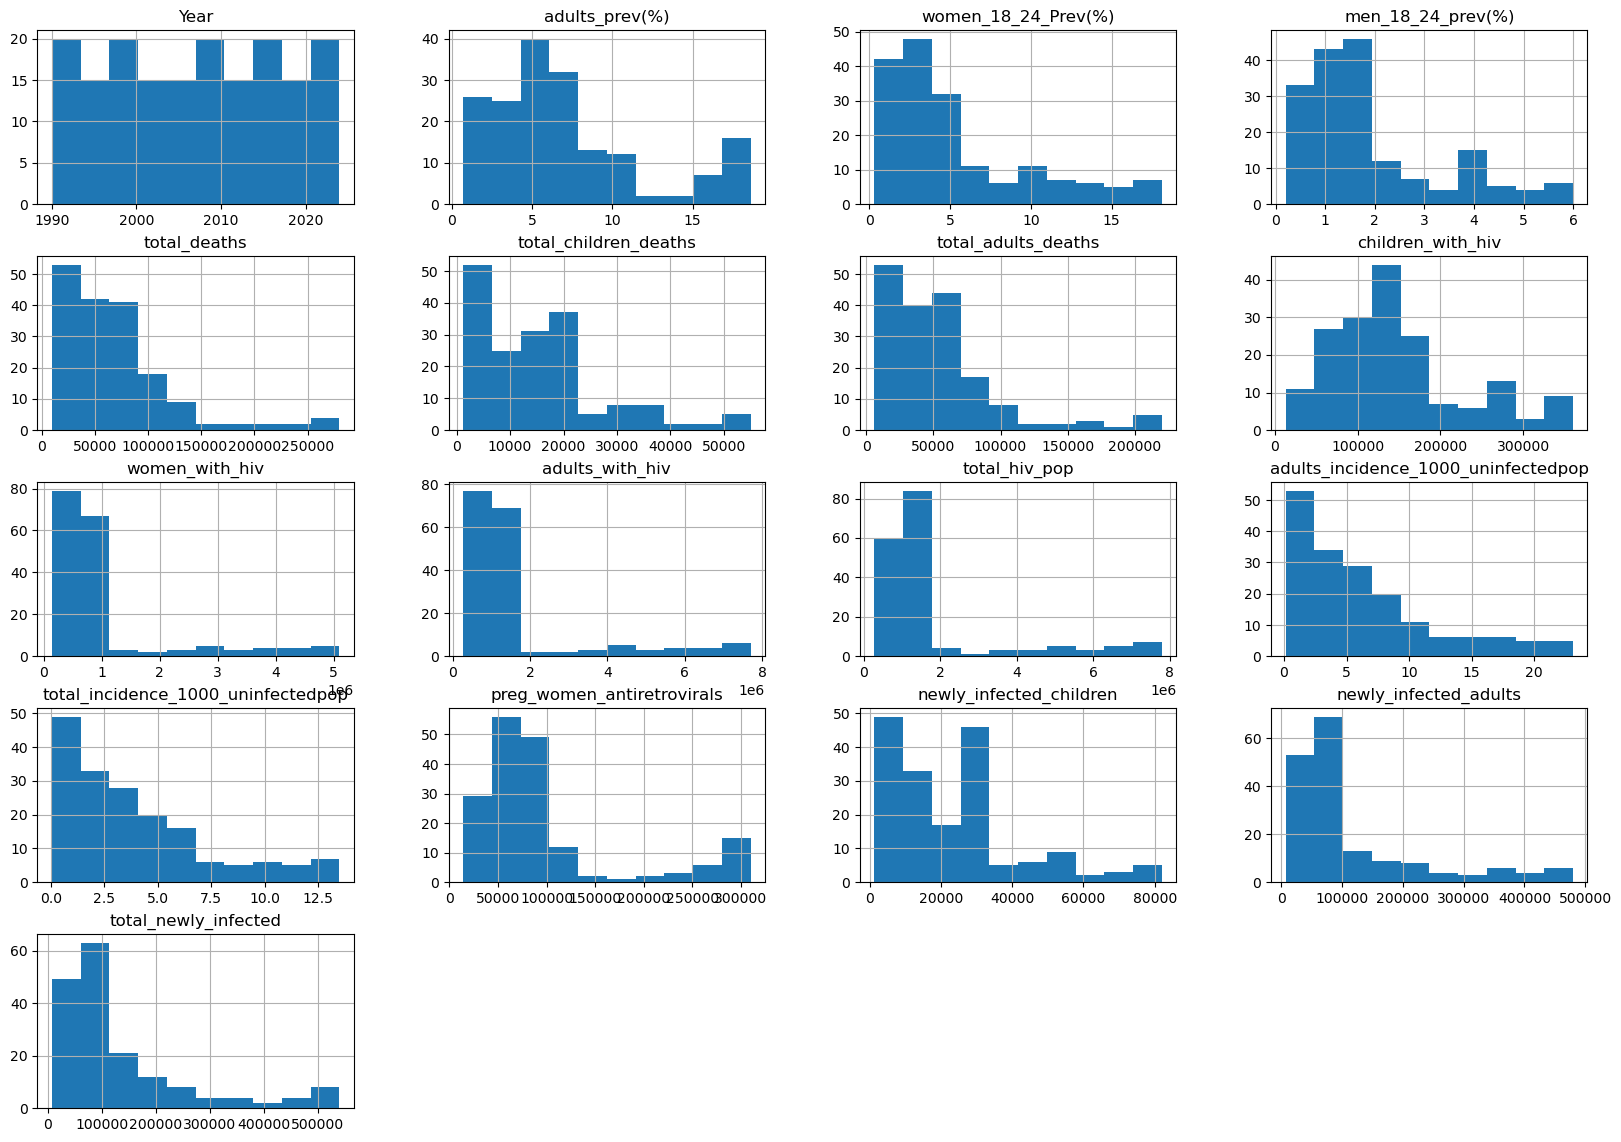

In [71]:
#Exploring the distribution of numeric columns
_=kenya_peers.hist(figsize=(20,14))

#### HIV INFECTION AMONG KENYA AND ITS PEERS

In [72]:
# Average Number of infections by country
kenya_peers.groupby('Code')['total_newly_infected'].mean().sort_values(ascending=False)

Code
ZAF    344285.714286
TZA    104285.714286
KEN    102542.857143
UGA     85028.571429
ETH     50525.714286
Name: total_newly_infected, dtype: Float64

In [73]:
#Average number of child infection by Country
kenya_peers.groupby('Code')['newly_infected_children'].mean().sort_values(ascending=False)

Code
ZAF    35471.428571
KEN    28017.142857
UGA    20805.714286
TZA    19885.714286
ETH    13454.285714
Name: newly_infected_children, dtype: Float64

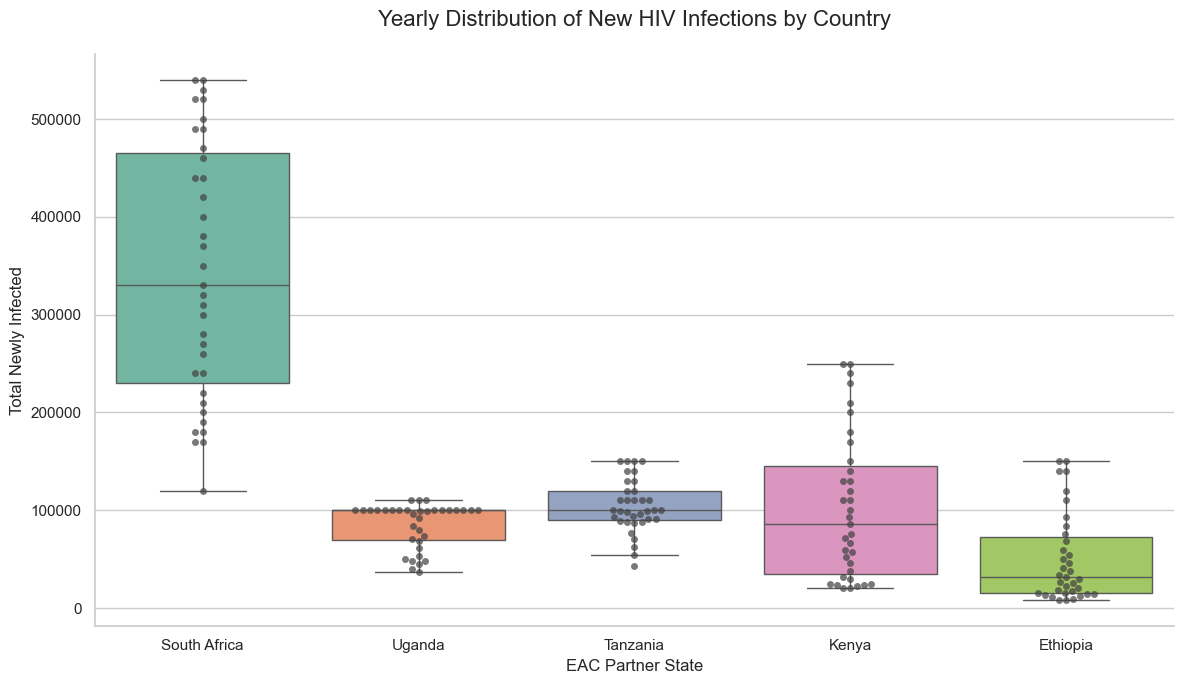

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns

fig=plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

# 1. Calculate order by median to keep it organized
order = kenya_peers.groupby('country')['total_newly_infected'].median().sort_values(ascending=False).index

# 2. Draw the boxplot (make it slightly lighter so dots stand out)
sns.boxplot(
    x='country', 
    y='total_newly_infected', 
    data=kenya_peers,
    order=order,
    palette="Set2", 
    fliersize=0  # Hide outliers in boxplot to avoid double-plotting them with the dots
)

# 3. Add the "Swarm" of data points
sns.swarmplot(
    x='country', 
    y='total_newly_infected', 
    data=kenya_peers,
    order=order,
    color="0.25", # Dark grey dots
    size=5,
    alpha=0.7
)

plt.title("Yearly Distribution of New HIV Infections by Country", fontsize=16, pad=20)
plt.xlabel("Country", fontsize=12)
plt.ylabel("Total Newly Infected", fontsize=12)
sns.despine()

plt.savefig("Yearly_Distribution_of_New_HIV_Infections_by_Country.png", dpi=300, bbox_inches='tight',facecolor=fig.get_facecolor())

plt.tight_layout()
plt.show()
 

The graph represents how new HIV infection rates have behaved over the years; the dots represent one year of data. Over the period from 1990 to 2024, there has been a massive difference between the "best" years and the "worst" years in Kenya and South Africa. In Kenya, for instance, new infections have swung from nearly 250,000 to almost zero. The squashed-view boxplots of Uganda and Tanzania indicate that the numbers of new infections have stayed relatively consistent over the years. The concentration of the dots at the bottom of Kenya's and Ethiopia's boxplots indicates that the two countries have managed to significantly push down the number of new HIV infections in recent years. Uganda has a very flat cluster of dots at the top of its box. This means that the numbers haven't changed much for a long stretch of time, or where there is a "ceiling" on the reported data.

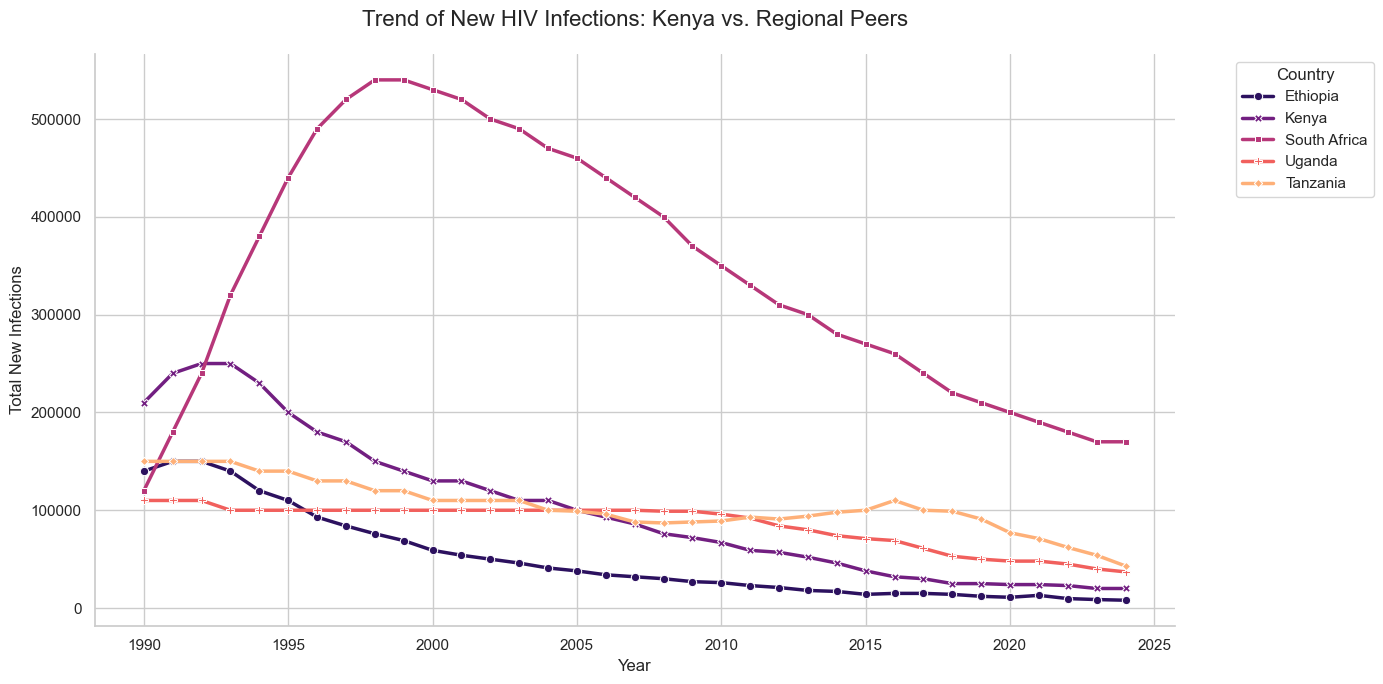

In [100]:
# Total number of HIV infections overtime
plt.figure(figsize=(14,7))
sns.set_theme(style='whitegrid')

sns.lineplot(
    data =kenya_peers,
    x='Year',
    y='total_newly_infected',
    hue = 'country',
    style='country',
    markers=True,
    dashes=False,
    linewidth=2.5,
    palette='magma',
    errorbar=None
)

# 3. Dynamic Title and Labels
plt.title("Trend of New HIV Infections: Kenya vs. Regional Peers", fontsize=16, pad=20)
plt.xlabel("Year", fontsize=12)
plt.ylabel("Total New Infections", fontsize=12)

# 4. Improve Legend Placement
# Putting the legend outside the plot prevents it from covering the data
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)

# 5. Clean up the 'spines' (the box around the plot)
sns.despine()

plt.tight_layout()
plt.show()


Since the year 2005, new HIV infections have relatively stayed below the 100,000 mark. This is not a coincidence because in 2005, that is when the U.S. President's Emergency Plan for AIDS Relief (PEPFAR) became fully operational, injecting billions of dollars in HIV treatment and in partnership with Global Fund, provided free or low-cost generic ARVs that played a significant role in reducing the viral load in populations. It is also in the same year that programmes for the prevention of mother-to-child transmission (PMTCT) became standard in many African clinics. This led to a drastic drop in the number of babies born with HIV. All these efforts also aligned with the World Health Organization's (WHO) "3 by 5" initiative that aimed to get 3 million people on treatment by the end of 2005.

In [101]:
#HIV NEW INFECTIONS PERCENT CHANGE(2005 VS 2024)

# Filter for just the two years we care about
years_of_interest = kenya_peers[kenya_peers['Year'].isin([2005, 2024])]

# Pivot the data so we have a column for 2005 and a column for 2024
pivot_df = years_of_interest.pivot(index='country', columns='Year', values='total_newly_infected')

# Calculate the percent change
pivot_df['pct_change'] = ((pivot_df[2024] - pivot_df[2005]) / pivot_df[2005]) * 100

# Reset index to make 'country' a column again for plotting
plot_data = pivot_df.reset_index().sort_values('pct_change')

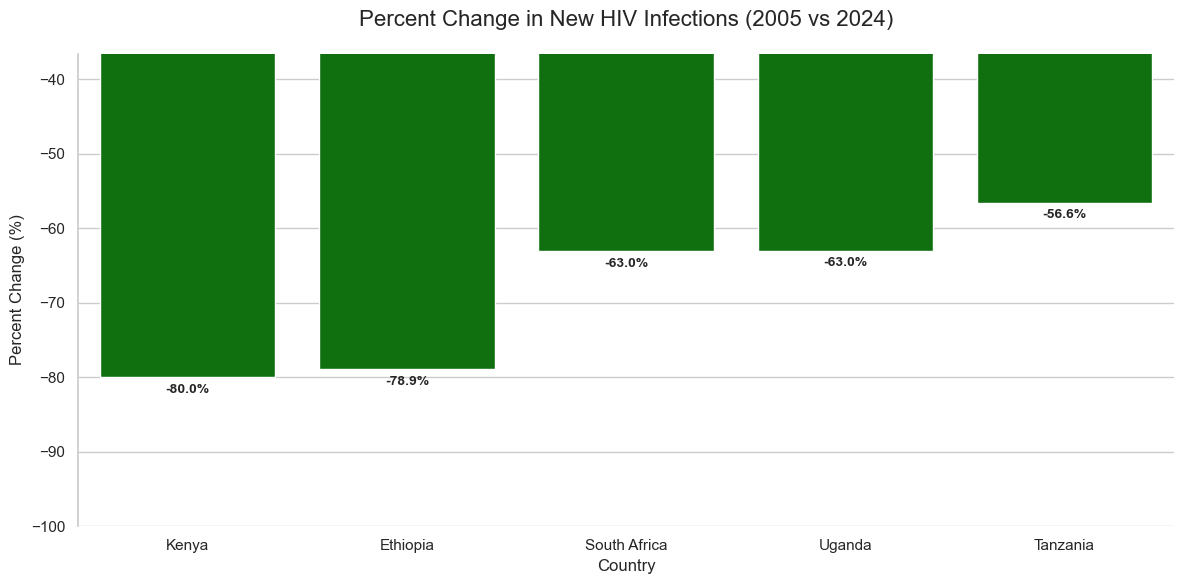

In [102]:
# Plot the data

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Create the barplot
# Using a diverging palette (Red for increase, Green for decrease)
colors = ['red' if x > 0 else 'green' for x in plot_data['pct_change']]

ax = sns.barplot(
    x='country', 
    y='pct_change', 
    data=plot_data, 
    palette=colors
)

# Add a horizontal line at 0 for reference
plt.axhline(0, color='black', linewidth=1)

# Add text labels on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height():.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9) if p.get_height() > 0 else (0, -9), 
                textcoords = 'offset points',
                fontsize=10, fontweight='bold')

plt.title("Percent Change in New HIV Infections (2005 vs 2024)", fontsize=16, pad=20)
plt.ylabel("Percent Change (%)")
plt.xlabel("Country")

# Set Y-axis limits slightly wider to accommodate labels
plt.ylim(plot_data['pct_change'].min() - 20, plot_data['pct_change'].max() + 20)

sns.despine(bottom=True)
plt.tight_layout()
plt.show()

Comparing 2005 and 2024(19yrs), Kenya and Ethiopia have reduced the number of new HIV infections at a higher rate compared to the rest of the countries.

#### HIV RELATED MORTALITIES AMONG KENYA AND ITS PEERS.

In [103]:
kenya_peers.head()

,Year,Code,country,adults_prev(%),women_18_24_Prev(%),men_18_24_prev(%),total_deaths,total_children_deaths,total_adults_deaths,children_with_hiv,women_with_hiv,adults_with_hiv,total_hiv_pop,adults_incidence_1000_uninfectedpop,total_incidence_1000_uninfectedpop,preg_women_antiretrovirals,newly_infected_children,newly_infected_adults,total_newly_infected
1680,1990,ETH,Ethiopia,2.2,2.3,0.7,20000,8700,11000,40000,250000,430000,470000,6.3,3.4,29000,20000,120000,140000
1681,1991,ETH,Ethiopia,2.6,2.7,0.8,26000,11000,15000,52000,320000,540000,590000,6.5,3.6,37000,24000,130000,150000
1682,1992,ETH,Ethiopia,3.0,3.0,0.8,33000,13000,20000,64000,380000,630000,700000,6.0,3.4,44000,26000,120000,150000
1683,1993,ETH,Ethiopia,3.3,3.1,0.8,40000,14000,26000,76000,430000,710000,790000,5.3,3.1,50000,28000,110000,140000
1684,1994,ETH,Ethiopia,3.4,3.1,0.8,47000,15000,31000,88000,460000,760000,850000,4.3,2.7,55000,29000,91000,120000


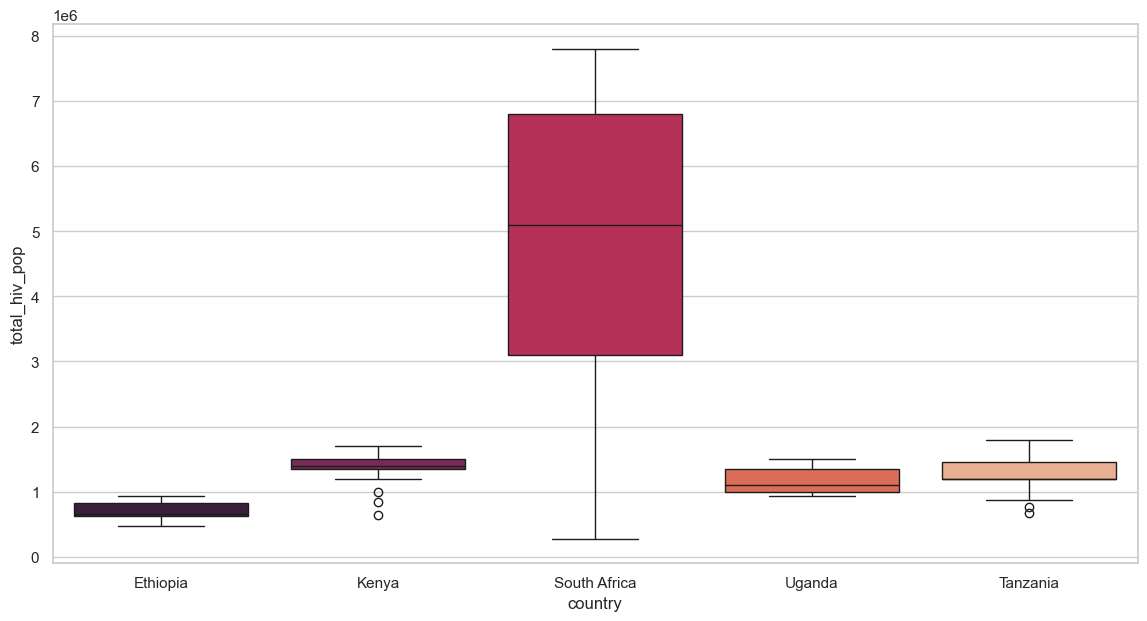

In [107]:
plt.figure(figsize=(14,7))
sns.boxplot(x='country',
           y='total_hiv_pop',
           data=kenya_peers,
           palette='rocket')
plt.show()